# Session 5: Humidity uncertainty and robust route choice

Session 4 found low-cost contrail-avoidance options, but several of those
routes pass many points close to ice saturation (RHi ≈ 1). This session
tests whether the route decisions survive plausible errors in ERA5
humidity.

**Scenarios** (pycontrails humidity scaling, applied inside PCR):
- `base`: unscaled ERA5 (as Sessions 1–4)
- `rhi_x0.95`: RHi ÷ 1.05 (≈5% drier)
- `rhi_x1.03`, `rhi_x1.05`, `rhi_x1.11`: RHi ÷ 0.97, 0.95, 0.90 (≈3%, 5%, 11% wetter)
- `boost`: pycontrails' `ExponentialBoostHumidityScaling` with default
  parameters (raises supersaturated values further)

These are sensitivity scenarios, not probabilities. The set leans wetter
because ERA5 is known to under-represent ice supersaturation.

**Decision rules compared**, for J = fuel + λ·(PCR km):
- deterministic: minimise J in the `base` scenario
- worst-case robust: minimise the largest J across scenarios
- minimax regret: minimise the largest gap between J and the best
  achievable J in each scenario

Fuel is unaffected by humidity, so Session 4's fuel values are reused.

In [3]:
import sys, warnings
from pathlib import Path
SRC = (Path("..") / "src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pycontrails.models.humidity_scaling import (
    ConstantHumidityScaling, ExponentialBoostHumidityScaling)

from contrail_routing.geometry import make_route, flight_level_to_m
from contrail_routing.met import load_era5, check_met_box
from contrail_routing.evaluate import evaluate_routes, route_metrics, pareto_mask

warnings.filterwarnings("ignore", message=r"\s*Met data appears to have originated from ECMWF")

results_dir = Path("..") / "results"
fig_dir = results_dir / "figures"
s5_dir = results_dir / "session5"
s5_dir.mkdir(parents=True, exist_ok=True)

ORIGIN, DEST = (-10.0, 45.0), (10.0, 55.0)
DEPARTURE = pd.Timestamp("2022-03-01 00:00")
CRUISE_SPEED_MS = 230.0
FLIGHT_LEVELS = [310, 320, 330, 340, 350, 360, 370, 380]
OFFSETS_KM = [-300, -150, 0, 150, 300]

def route_label(offset_km, fl):
    side = "GC" if offset_km == 0 else ("NW" if offset_km > 0 else "SE")
    return f"{side}{abs(offset_km)}_FL{fl}"

specs = {route_label(o, fl): {"offset_km": o, "flight_level": fl,
                              "altitude_m": round(flight_level_to_m(fl), 1)}
         for fl in FLIGHT_LEVELS for o in OFFSETS_KM}
routes = {n: make_route(ORIGIN, DEST, s["offset_km"], s["altitude_m"],
                        DEPARTURE, CRUISE_SPEED_MS, name=n)
          for n, s in specs.items()}

met_session5 = load_era5(time=("2022-03-01T00", "2022-03-01T06"),
                         pressure_levels=[200, 225, 250, 275, 300])
print(check_met_box(met_session5, (-15, 15), (40, 60)))

m4 = pd.read_csv(results_dir / "session4_route_metrics.csv").set_index("route")
fuel = m4["fuel_kg"]
print(f"\n{len(routes)} routes rebuilt; fuel loaded for {fuel.notna().sum()} routes.")
assert set(routes) == set(fuel.index), "Route names differ from Session 4"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
                 time  air_temperature_nan  specific_humidity_nan
0 2022-03-01 00:00:00                    0                      0
1 2022-03-01 01:00:00                    0                      0
2 2022-03-01 02:00:00                    0                      0
3 2022-03-01 03:00:00                    0                      0
4 2022-03-01 04:00:00                    0                      0
5 2022-03-01 05:00:00                    0                      0
6 2022-03-01 06:00:00                    0                      0

40 routes rebuilt; fuel loaded for 40 routes.


In [5]:
SCENARIOS = {
    "base": None,
    "rhi_x0.95": ConstantHumidityScaling(rhi_adj=1.05),
    "rhi_x1.03": ConstantHumidityScaling(rhi_adj=0.97),
    "rhi_x1.05": ConstantHumidityScaling(rhi_adj=0.95),
    "rhi_x1.11": ConstantHumidityScaling(rhi_adj=0.90),
    "boost": ExponentialBoostHumidityScaling(),
}

test_name = "GC0_FL360"
rows = []
for scen, scaler in SCENARIOS.items():
    t = evaluate_routes({test_name: routes[test_name]}, met_session5,
                        humidity_scaling=scaler)[test_name]
    issr_mismatch = int(((t["ISSR"] > 0) != (t["rhi"] > 1.0)).sum())
    rows.append({"scenario": scen,
                 "pcr_km": t.loc[t["PCR"] > 0, "leg_km"].sum(),
                 "rhi_max": t["rhi"].max(),
                 "rhi_mean": t["rhi"].mean(),
                 "ISSR_vs_RHi>1_mismatch": issr_mismatch})
test_df = pd.DataFrame(rows)
print(test_df.round(3).to_string(index=False))
print(f"\nSession 4 baseline for {test_name}: {m4.loc[test_name, 'pcr_km']:.1f} km")

Evaluated 1 routes, no missing values.
Evaluated 1 routes, no missing values.
Evaluated 1 routes, no missing values.
Evaluated 1 routes, no missing values.
Evaluated 1 routes, no missing values.
Evaluated 1 routes, no missing values.
 scenario  pcr_km  rhi_max  rhi_mean  ISSR_vs_RHi>1_mismatch
     base   400.2    1.097     0.879                       0
rhi_x0.95   276.0    1.044     0.837                       0
rhi_x1.03   607.2    1.130     0.906                       0
rhi_x1.05   731.4    1.154     0.925                       0
rhi_x1.11  1062.6    1.218     0.977                       0
    boost   607.2    1.232     0.923                       0

Session 4 baseline for GC0_FL360: 400.2 km


In [6]:
def run_scenario(name, scaler):
    """Evaluate all 40 routes for one scenario, or reload them if already saved."""
    path = s5_dir / f"along_track_{name}.csv"
    if path.exists():
        df = pd.read_csv(path, parse_dates=["time"])
        print(f"{name:10s} loaded from disk")
        return {r: g.reset_index(drop=True) for r, g in df.groupby("route", sort=False)}
    print(f"{name:10s} evaluating 40 routes ...")
    tables = evaluate_routes(routes, met_session5, humidity_scaling=scaler)
    pd.concat(tables.values(), ignore_index=True).to_csv(path, index=False)
    return tables

scenario_tables = {name: run_scenario(name, scaler) for name, scaler in SCENARIOS.items()}

base_m = route_metrics(scenario_tables["base"], specs).set_index("route")
max_diff = (base_m["pcr_km"] - m4.loc[base_m.index, "pcr_km"]).abs().max()
print(f"\nMax |base - Session 4| pcr_km: {max_diff:.6f}")
assert max_diff < 1e-6
print("Base scenario matches Session 4.")

base       evaluating 40 routes ...
Evaluated 40 routes, no missing values.
rhi_x0.95  evaluating 40 routes ...
Evaluated 40 routes, no missing values.
rhi_x1.03  evaluating 40 routes ...
Evaluated 40 routes, no missing values.
rhi_x1.05  evaluating 40 routes ...
Evaluated 40 routes, no missing values.
rhi_x1.11  evaluating 40 routes ...
Evaluated 40 routes, no missing values.
boost      evaluating 40 routes ...
Evaluated 40 routes, no missing values.

Max |base - Session 4| pcr_km: 0.000000
Base scenario matches Session 4.


In [7]:
pcr = pd.DataFrame({
    name: route_metrics(tables, specs).set_index("route")["pcr_km"]
    for name, tables in scenario_tables.items()
})
pcr = pcr.loc[m4.index]

key = ["GC0_FL380", "GC0_FL370", "GC0_FL360", "NW150_FL360", "NW300_FL360",
       "GC0_FL340", "NW150_FL340", "NW150_FL320", "NW300_FL340"]
print("PCR km by scenario (key routes):")
print(pcr.loc[key].round(1).to_string())

print("\nRoutes contrail-free in every scenario:")
print(pcr.index[pcr.max(axis=1) == 0].tolist())

pcr.to_csv(results_dir / "session5_pcr_by_scenario.csv")

PCR km by scenario (key routes):
               base  rhi_x0.95  rhi_x1.03  rhi_x1.05  rhi_x1.11   boost
route                                                                  
GC0_FL380       0.0        0.0        0.0        0.0        0.0     0.0
GC0_FL370       0.0        0.0        0.0        0.0        0.0     0.0
GC0_FL360     400.2      276.0      607.2      731.4     1062.6   607.2
NW150_FL360    69.0       13.8      179.4      234.6      427.8   179.4
NW300_FL360    41.4       13.8       55.2       96.6      262.2    55.2
GC0_FL340    1035.0      565.8     1352.4     1504.2     1642.2  1352.4
NW150_FL340   372.6      165.6      441.6      510.6      676.2   441.6
NW150_FL320   331.2       27.6      524.4      717.6     1145.4   524.4
NW300_FL340   276.0       96.6      414.0      469.2      593.4   414.0

Routes contrail-free in every scenario:
['SE300_FL370', 'SE150_FL370', 'GC0_FL370', 'NW150_FL370', 'NW300_FL370', 'SE300_FL380', 'SE150_FL380', 'GC0_FL380', 'NW150_FL380', 'N

In [8]:
LAMBDAS = [0.1, 1.0, 10.0]   # kg fuel per km of PCR flight avoided
CEILINGS = [380, 360, 340]

def choose(candidates, lam):
    J = pcr.loc[candidates].mul(lam).add(fuel.loc[candidates], axis=0)   # routes x scenarios
    regret = J - J.min(axis=0)
    picks = {
        "deterministic": J["base"].idxmin(),
        "worst_case": J.max(axis=1).idxmin(),
        "min_regret": regret.max(axis=1).idxmin(),
    }
    rows = []
    for rule, r in picks.items():
        rows.append({"rule": rule, "route": r, "fuel_kg": fuel[r],
                     "pcr_base_km": pcr.at[r, "base"],
                     "pcr_worst_km": pcr.loc[r].max(),
                     "pcr_mean_km": pcr.loc[r].mean(),
                     "max_regret_kg": regret.loc[r].max()})
    out = pd.DataFrame(rows)
    out["extra_fuel_vs_det_kg"] = out["fuel_kg"] - out.loc[out["rule"] == "deterministic", "fuel_kg"].iloc[0]
    return out

decisions = []
for ceiling in CEILINGS:
    cands = m4.index[m4["flight_level"] <= ceiling]
    for lam in LAMBDAS:
        d = choose(cands, lam)
        d.insert(0, "lambda", lam)
        d.insert(0, "ceiling_FL", ceiling)
        decisions.append(d)
decisions = pd.concat(decisions, ignore_index=True)
pd.set_option("display.width", 220)
print(decisions.round(1).to_string(index=False))
decisions.to_csv(results_dir / "session5_robust_decisions.csv", index=False)

 ceiling_FL  lambda          rule       route  fuel_kg  pcr_base_km  pcr_worst_km  pcr_mean_km  max_regret_kg  extra_fuel_vs_det_kg
        380     0.1 deterministic   GC0_FL380   5060.7          0.0           0.0          0.0            0.0                   0.0
        380     0.1    worst_case   GC0_FL380   5060.7          0.0           0.0          0.0            0.0                   0.0
        380     0.1    min_regret   GC0_FL380   5060.7          0.0           0.0          0.0            0.0                   0.0
        380     1.0 deterministic   GC0_FL380   5060.7          0.0           0.0          0.0            0.0                   0.0
        380     1.0    worst_case   GC0_FL380   5060.7          0.0           0.0          0.0            0.0                   0.0
        380     1.0    min_regret   GC0_FL380   5060.7          0.0           0.0          0.0            0.0                   0.0
        380    10.0 deterministic   GC0_FL380   5060.7          0.0         

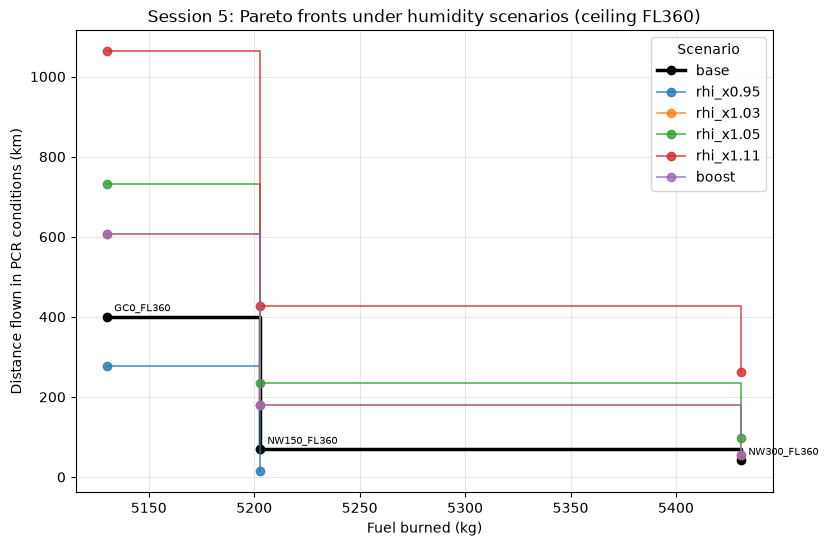

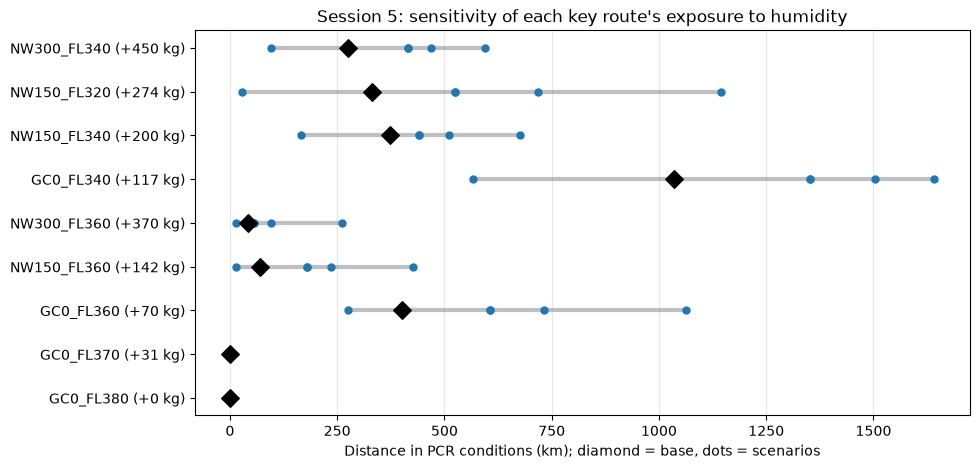

In [9]:
# 1. Pareto fronts per scenario, ceiling FL360
cands = m4.index[m4["flight_level"] <= 360]
fig, ax = plt.subplots(figsize=(9, 6))
for scen in pcr.columns:
    sub = pd.DataFrame({"fuel_kg": fuel.loc[cands], "pcr_km": pcr.loc[cands, scen]})
    f = sub[pareto_mask(sub)].sort_values("fuel_kg")
    style = dict(linewidth=2.5, color="k") if scen == "base" else dict(linewidth=1.2, alpha=0.8)
    ax.step(f["fuel_kg"], f["pcr_km"], where="post", marker="o", label=scen, **style)
    if scen == "base":
        for r, row in f.iterrows():
            ax.annotate(r, (row["fuel_kg"], row["pcr_km"]), textcoords="offset points",
                        xytext=(5, 4), fontsize=7)
ax.set_xlabel("Fuel burned (kg)")
ax.set_ylabel("Distance flown in PCR conditions (km)")
ax.set_title("Session 5: Pareto fronts under humidity scenarios (ceiling FL360)")
ax.grid(alpha=0.3)
ax.legend(title="Scenario")
fig.savefig(fig_dir / "session5_fronts_by_scenario_FL360.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Exposure range for the key routes
fig, ax = plt.subplots(figsize=(10, 5))
for i, r in enumerate(key):
    ax.plot([pcr.loc[r].min(), pcr.loc[r].max()], [i, i], color="grey", linewidth=3, alpha=0.5)
    ax.scatter(pcr.loc[r], [i] * len(pcr.columns), s=25, color="tab:blue", zorder=3)
    ax.scatter(pcr.at[r, "base"], i, s=80, marker="D", color="k", zorder=4)
ax.set_yticks(range(len(key)))
ax.set_yticklabels([f"{r} (+{fuel[r] - fuel.min():.0f} kg)" for r in key])
ax.set_xlabel("Distance in PCR conditions (km); diamond = base, dots = scenarios")
ax.set_title("Session 5: sensitivity of each key route's exposure to humidity")
ax.grid(alpha=0.3, axis="x")
fig.savefig(fig_dir / "session5_exposure_ranges.png", dpi=150, bbox_inches="tight")
plt.show()